# Results Checking

Thorough audit of the result files: **coverage** (what the config says should exist vs. what's on disk), **completeness** (folds < `cv_splits`, malformed files), **sanity** (NaN / out-of-range / worse-than-random metrics), **stale** files, and **visualisations** (dataset×method coverage heatmaps, fold completeness, metric distributions, sweep curves).

All logic lives in [`src/utils/results_checking.py`](../src/utils/results_checking.py); this notebook is a thin viewer. It transparently handles **both** result layouts: one file per `(dataset, method)` point (Experiment 0/1), and **packed** files where all of a cell's sweep points live in a single `<method>.json` (Experiment 2/3, metrics only — no prediction arrays).

> **Where to run:** wherever the results live. On the cluster the results are on the Lustre **project storage** (`<project_storage>/results`), which the OnDemand *file browser* cannot see — open a **VSCode session in OnDemand** (it *can* see Lustre) and run this notebook there, or run it locally against a downloaded copy. Set `RESULTS_ROOT` below accordingly.

In [1]:
import sys
from pathlib import Path

# Make `import src.*` work when running from the notebooks/ folder.
_REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.utils import results_checking as rc
from src.utils.paths import results_root

# None -> auto-resolve ($TABPFN_RESULTS_ROOT / project-storage / ./results).
# On the cluster you can pin it explicitly, e.g.:
#   RESULTS_ROOT = '<project_storage>/results'
RESULTS_ROOT = None
print('Results root:', RESULTS_ROOT or results_root())

Results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results


## 1. One-call overview (all experiments)

Headline tables + plots for every experiment. Drill into any one in the sections below.

  Experiment0


results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),840
present on disk,840
complete (>= cv folds),840
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,7
"STALE (on disk, not in config)",0



-- 7 ANOMALOUS (showing up to 30) --
task           dataset      name base_method                            issues
 lgd   0004.base_model      dnnr        dnnr         R2 very negative (-1.623)
  pd         0001.gmsc     ptarl       ptarl AUC<0.5 worse-than-random (0.292)
  pd 0003.vehicle_loan     ptarl       ptarl AUC<0.5 worse-than-random (0.492)
  pd 0011.loan_default modernNCA   modernNCA AUC<0.5 worse-than-random (0.480)
  pd 0011.loan_default     ptarl       ptarl AUC<0.5 worse-than-random (0.479)
  pd  0012.home_credit   tabcaps     tabcaps AUC<0.5 worse-than-random (0.469)
  pd  0012.home_credit    tabnet      tabnet AUC<0.5 worse-than-random (0.486)


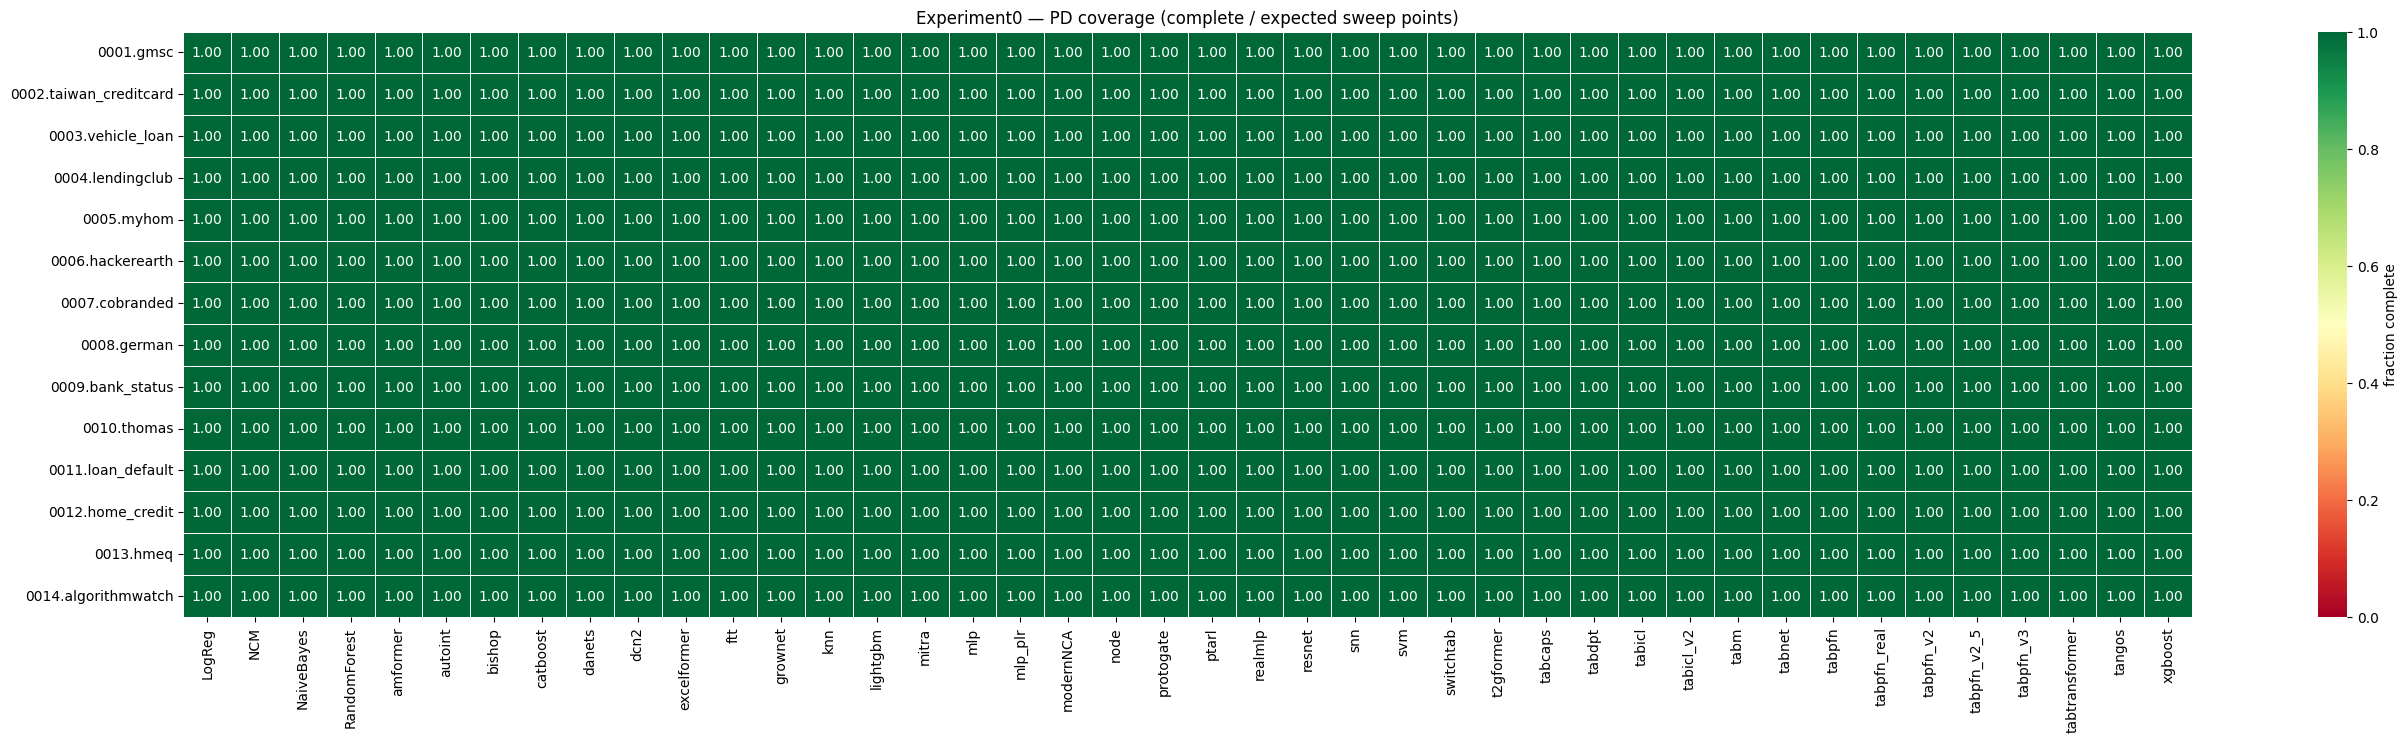

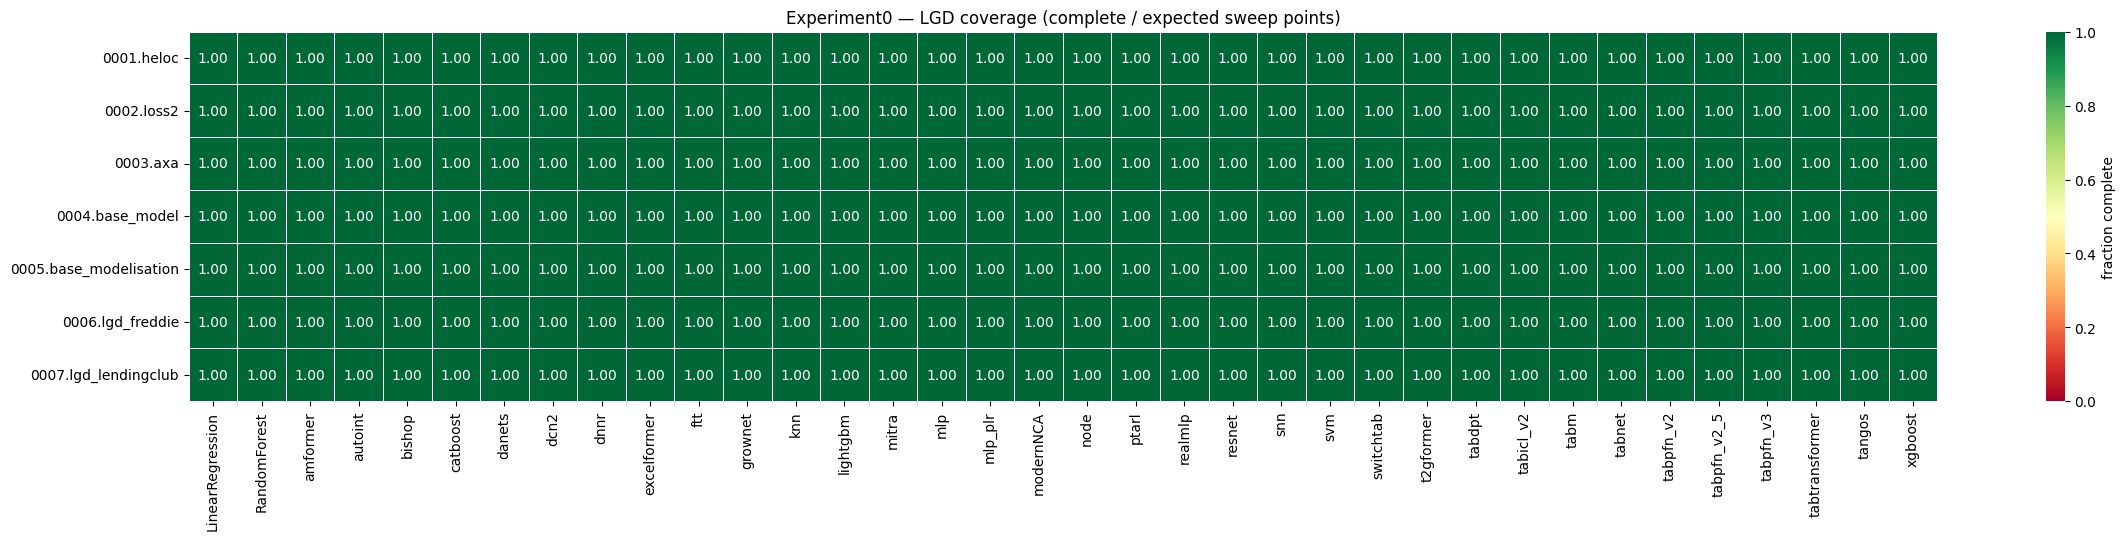

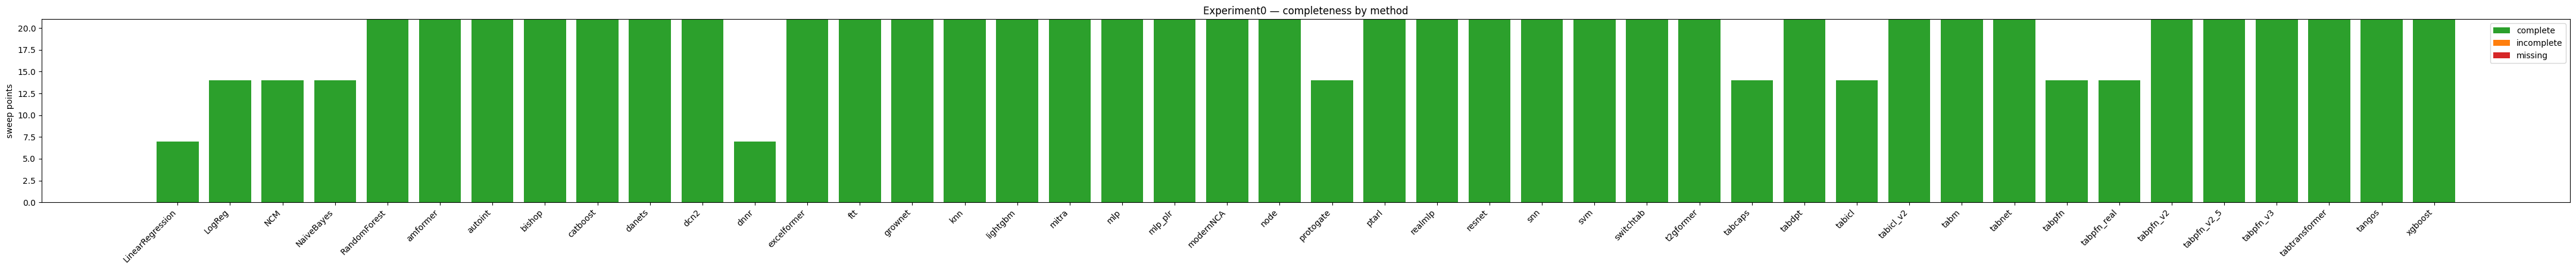

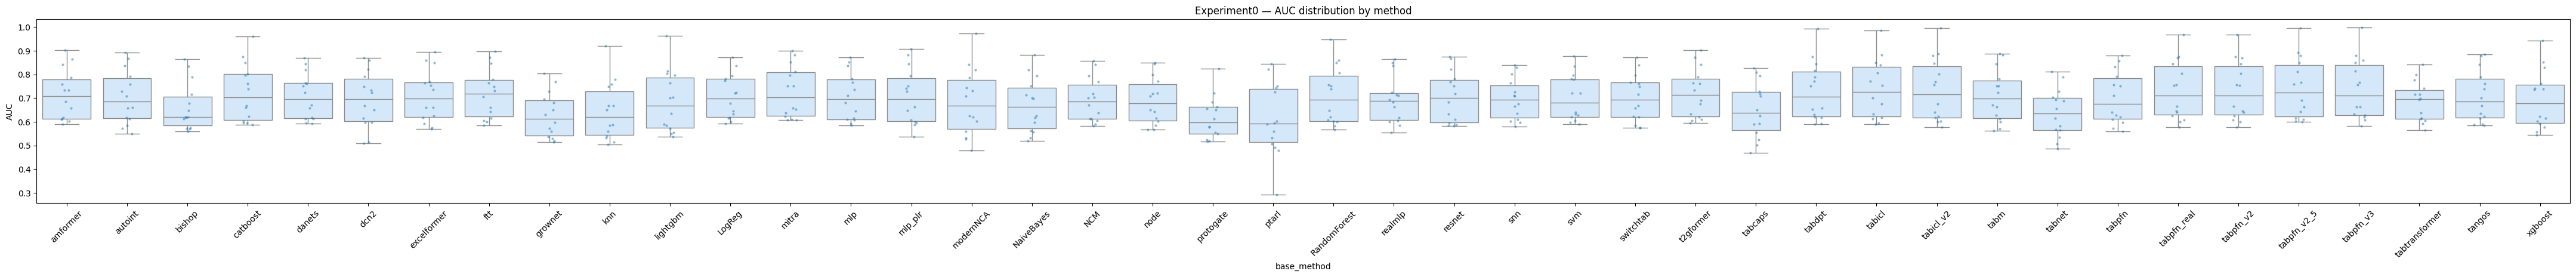


  Experiment1


results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),1302
present on disk,1302
complete (>= cv folds),1302
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,1
"STALE (on disk, not in config)",0



-- 1 ANOMALOUS (showing up to 30) --
task           dataset         name base_method                             issues
  pd 0011.loan_default xgboost__HPO     xgboost AUC identical across folds (std=0)


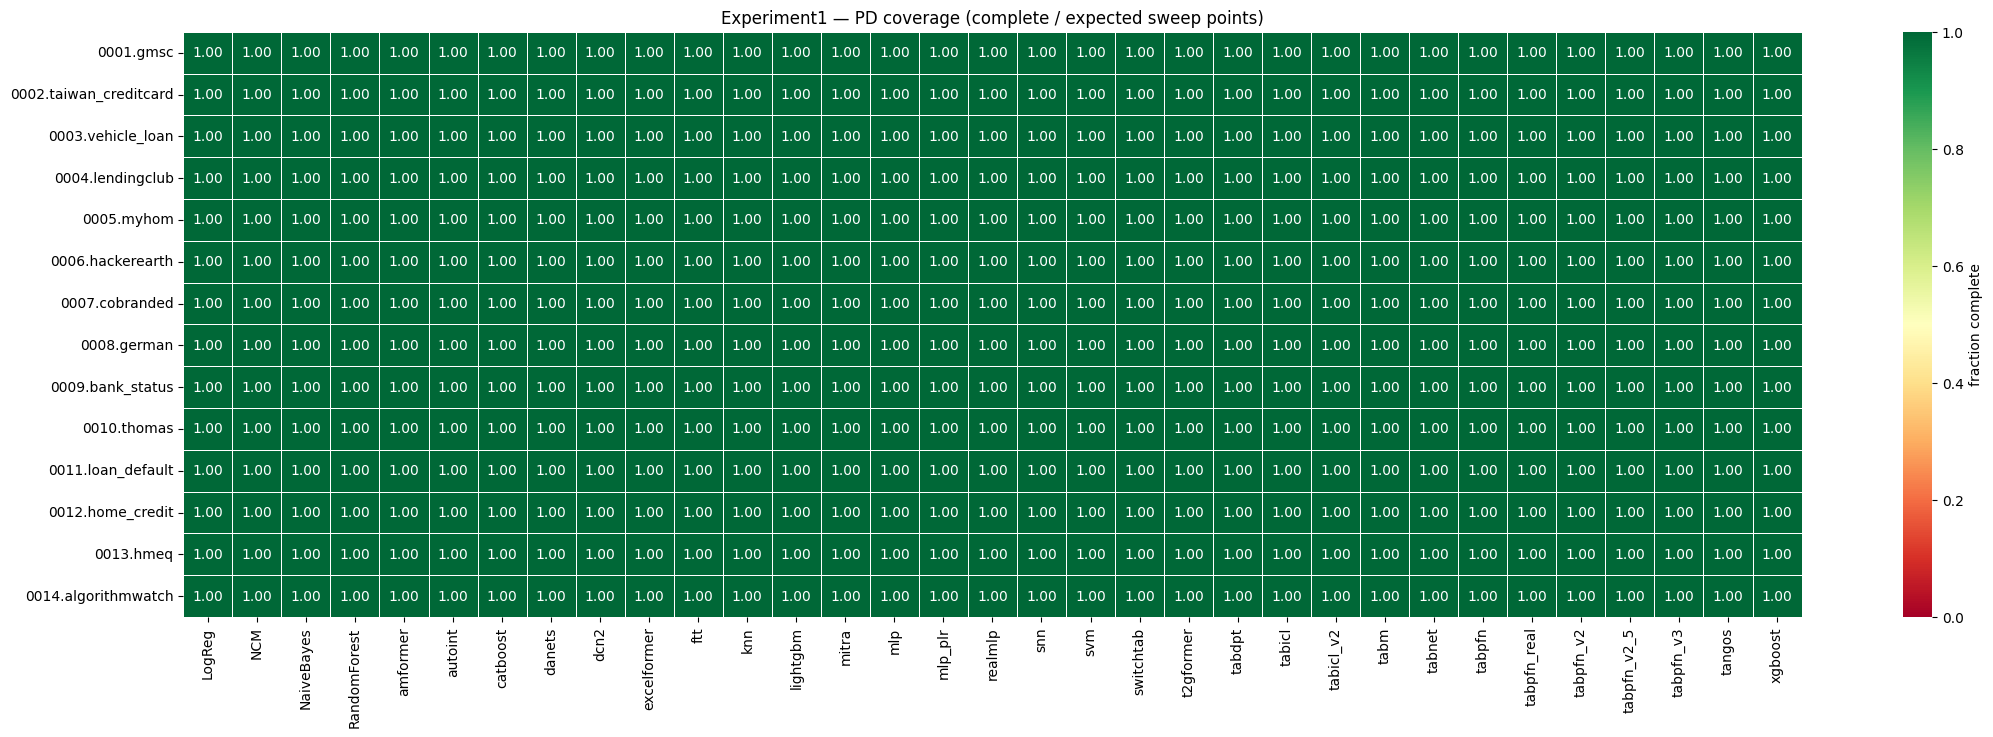

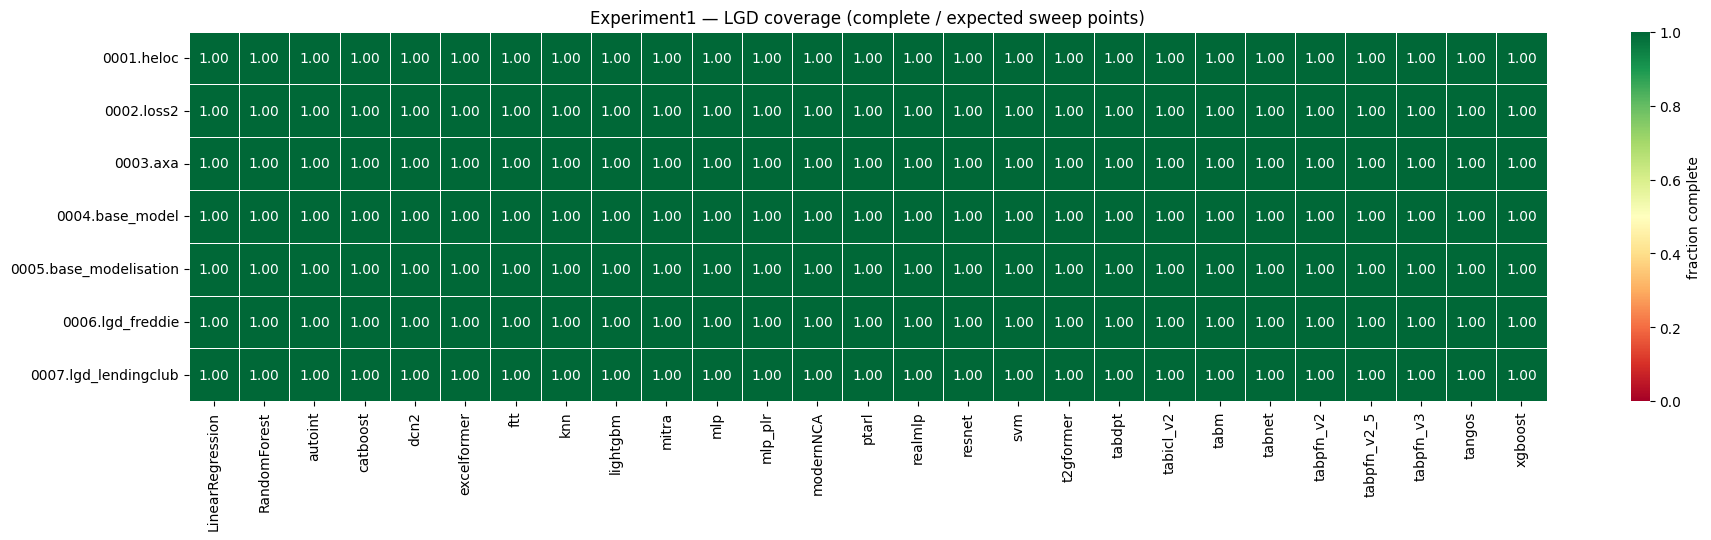

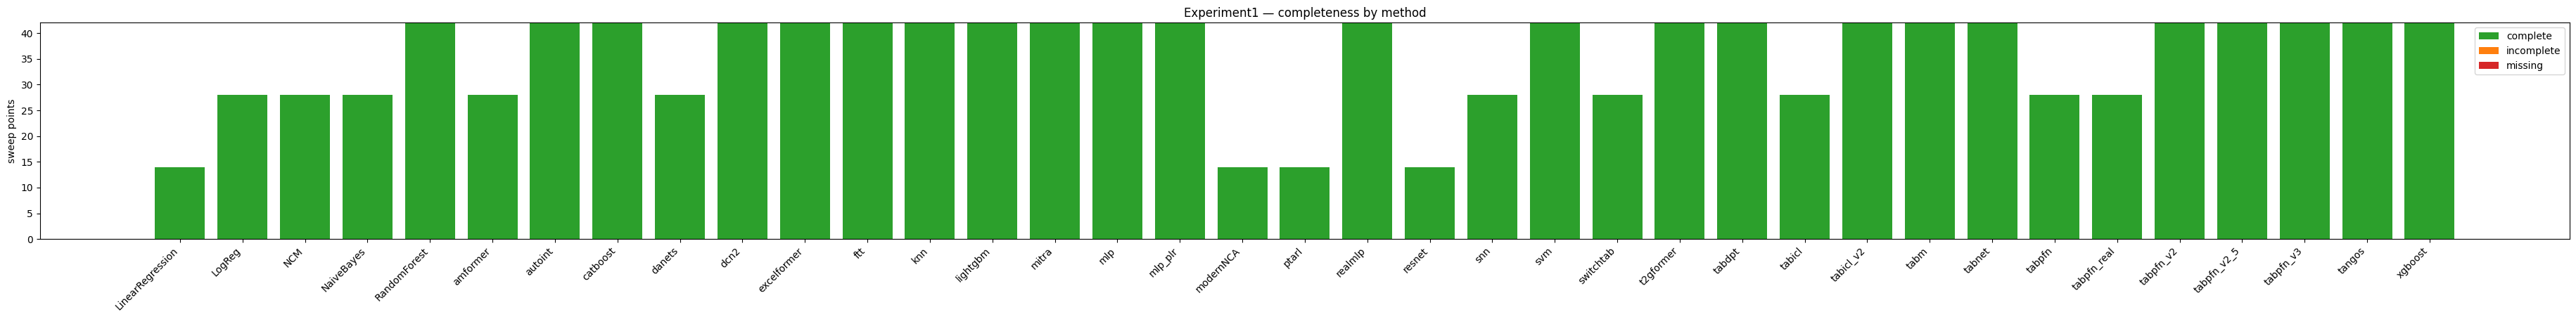

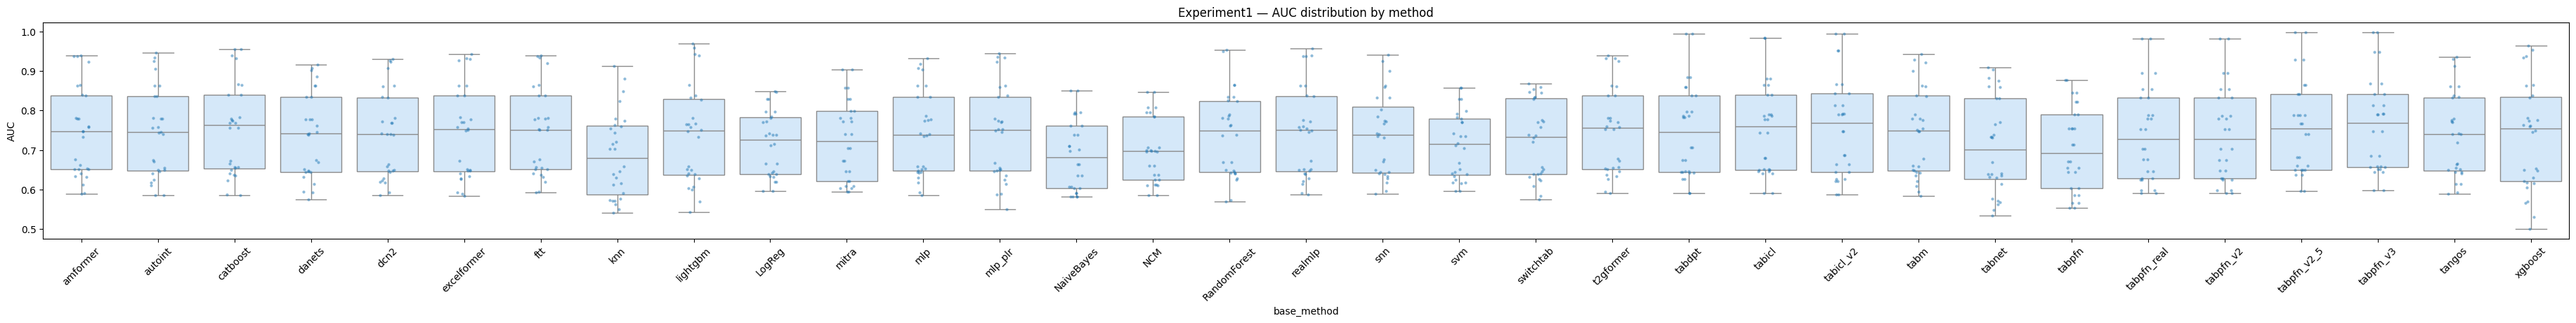


  Experiment2


results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),50308
present on disk,50308
complete (>= cv folds),50308
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,119
"STALE (on disk, not in config)",0



-- 119 ANOMALOUS (showing up to 30) --
task           dataset                     name      base_method                            issues
 lgd        0002.loss2 LinearRegression__row100 LinearRegression         R2 very negative (-1.052)
  pd 0003.vehicle_loan        tabicl_v2__row200        tabicl_v2 AUC<0.5 worse-than-random (0.497)
  pd 0003.vehicle_loan        tabpfn_v3__row175        tabpfn_v3 AUC<0.5 worse-than-random (0.495)
  pd 0003.vehicle_loan          xgboost__row325          xgboost AUC<0.5 worse-than-random (0.488)
  pd  0006.hackerearth          xgboost__row175          xgboost AUC<0.5 worse-than-random (0.482)
  pd  0009.bank_status          xgboost__row275          xgboost AUC<0.5 worse-than-random (0.492)
  pd  0009.bank_status          xgboost__row225          xgboost AUC<0.5 worse-than-random (0.484)
  pd  0009.bank_status          xgboost__row200          xgboost AUC<0.5 worse-than-random (0.475)
  pd  0009.bank_status          xgboost__row175          xgboost AUC<

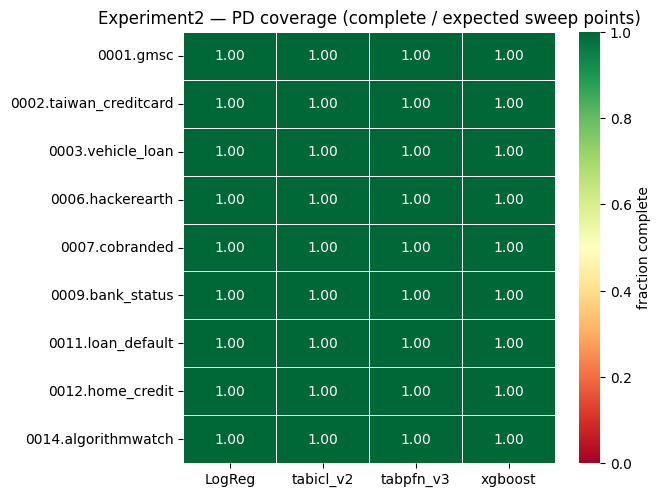

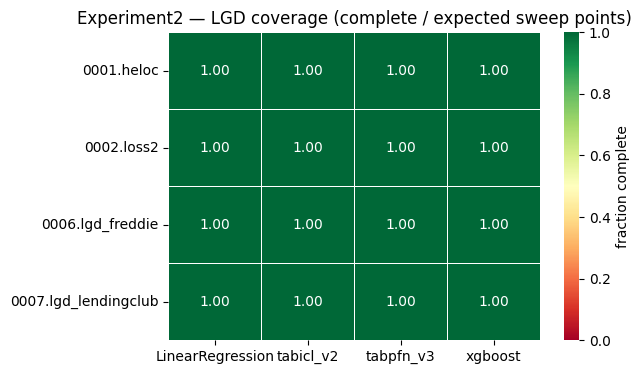

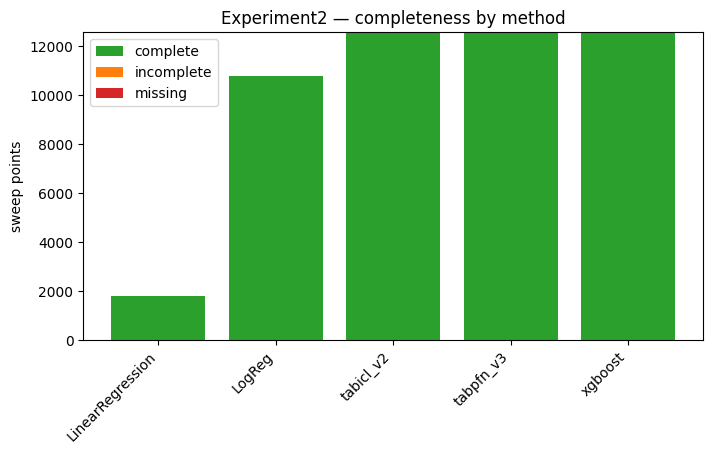

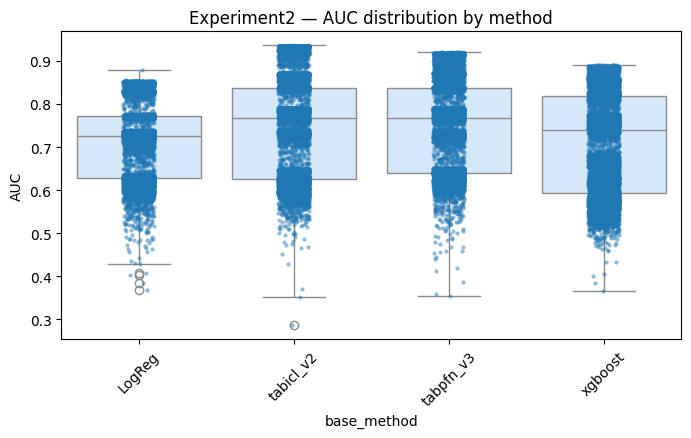

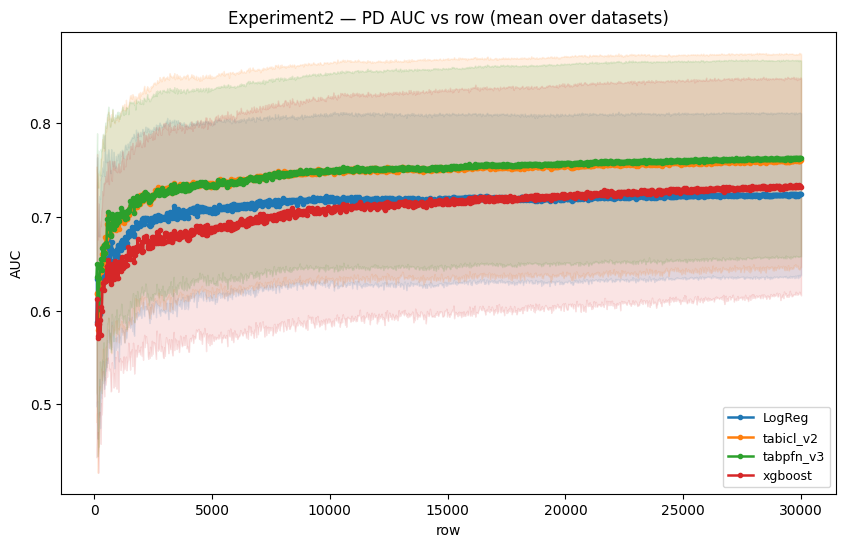

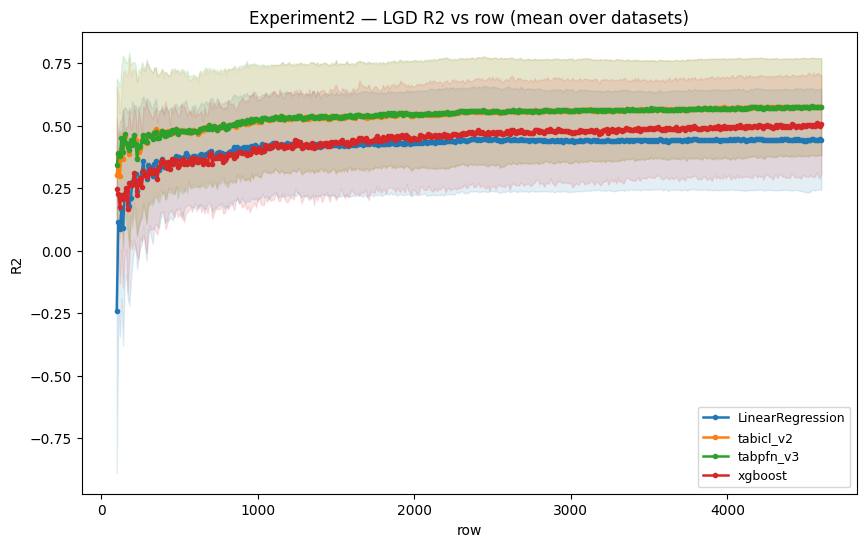


  Experiment3


results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),7104
present on disk,7104
complete (>= cv folds),7104
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,0
"STALE (on disk, not in config)",0


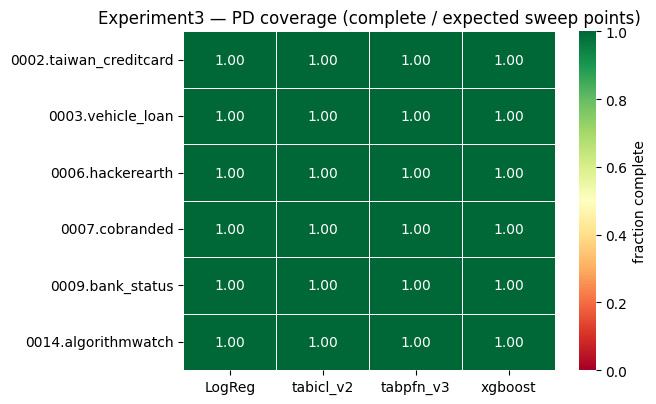

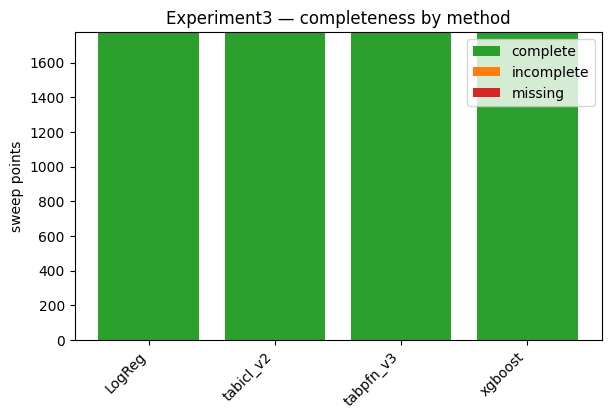

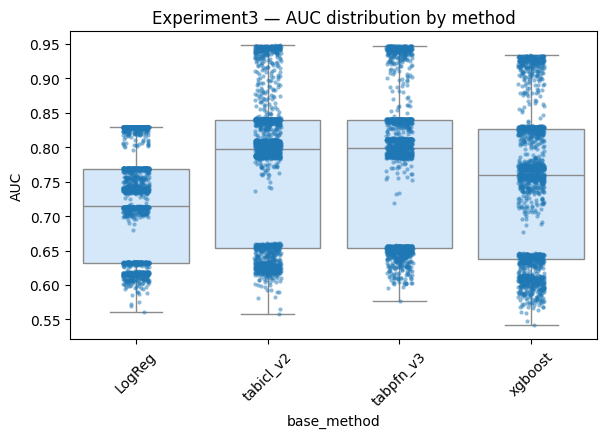

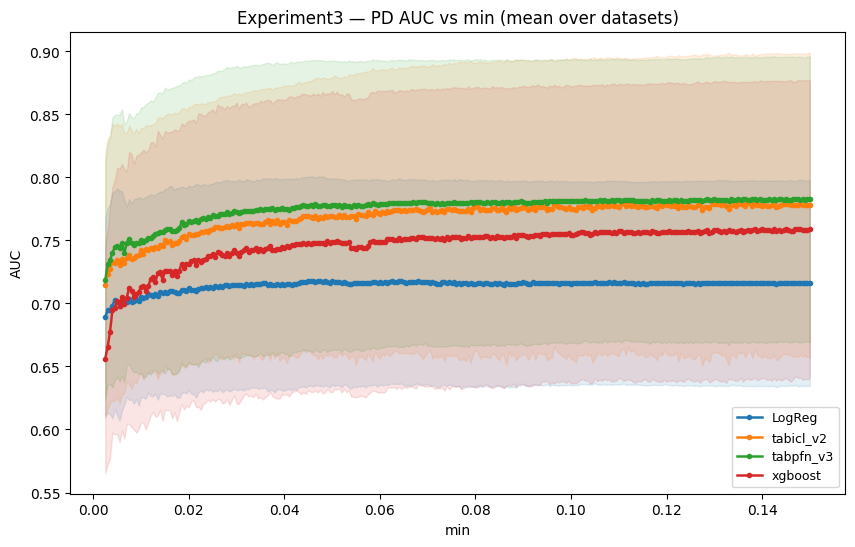

In [2]:
audits = rc.run_full_audit(
    experiments=('Experiment0', 'Experiment1', 'Experiment2', 'Experiment3'),
    results_root=RESULTS_ROOT,
    show_plots=True,
)

## 2. Drill into one experiment

Set `EXP` and re-run the cells below.

In [3]:
EXP = 'Experiment2'
audit = rc.audit_experiment(EXP, results_root=RESULTS_ROOT)
audit.summary()

,count
check,
expected (from config),50308
present on disk,50308
complete (>= cv folds),50308
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,119
"STALE (on disk, not in config)",0


In [4]:
# What's MISSING (expected by the config but absent on disk)
audit.missing_frame()

,task,dataset,name,base_method


In [5]:
# INCOMPLETE (fewer folds than cv_splits) and MALFORMED / unreadable files
display(audit.incomplete_frame())
from src.utils.results_checking import _combo_frame
display(_combo_frame(audit.malformed))

,task,dataset,name,base_method


,task,dataset,name,base_method


In [6]:
# ANOMALOUS results (NaN/inf, out-of-range, worse-than-random AUC, ...)
audit.anomalies_frame()

,task,dataset,name,base_method,issues
0,lgd,0002.loss2,LinearRegression__row100,LinearRegression,R2 very negative (-1.052)
1,pd,0003.vehicle_loan,tabicl_v2__row200,tabicl_v2,AUC<0.5 worse-than-random (0.497)
2,pd,0003.vehicle_loan,tabpfn_v3__row175,tabpfn_v3,AUC<0.5 worse-than-random (0.495)
3,pd,0003.vehicle_loan,xgboost__row325,xgboost,AUC<0.5 worse-than-random (0.488)
4,pd,0006.hackerearth,xgboost__row175,xgboost,AUC<0.5 worse-than-random (0.482)
...,...,...,...,...,...
114,pd,0014.algorithmwatch,xgboost__row400,xgboost,AUC<0.5 worse-than-random (0.459)
115,pd,0014.algorithmwatch,xgboost__row300,xgboost,AUC<0.5 worse-than-random (0.470)
116,pd,0014.algorithmwatch,xgboost__row175,xgboost,AUC<0.5 worse-than-random (0.494)
117,pd,0014.algorithmwatch,xgboost__row125,xgboost,AUC<0.5 worse-than-random (0.489)


In [7]:
# STALE files on disk that are NOT in the current config (disabled method, old sweep, ...)
audit.stale_frame()

,task,dataset,name,base_method


## Sweep coverage (Exp 2 / Exp 3) — one line per method, averaged over datasets

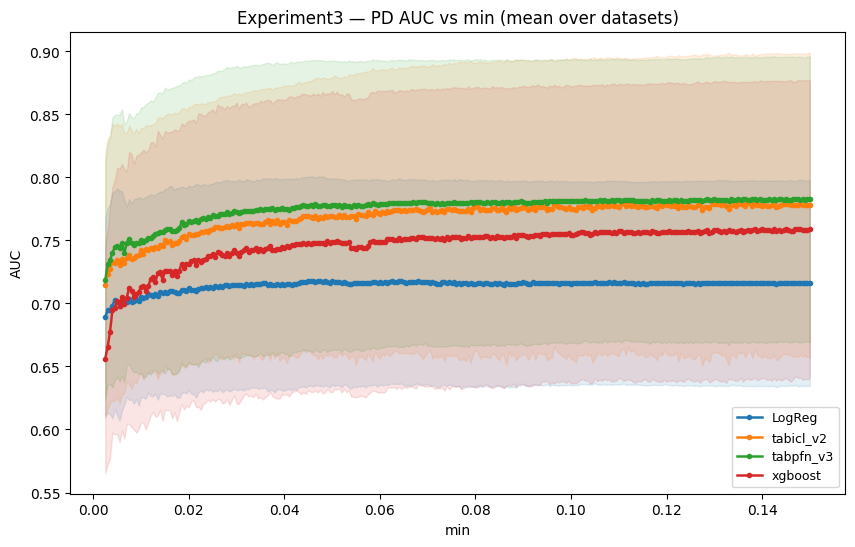

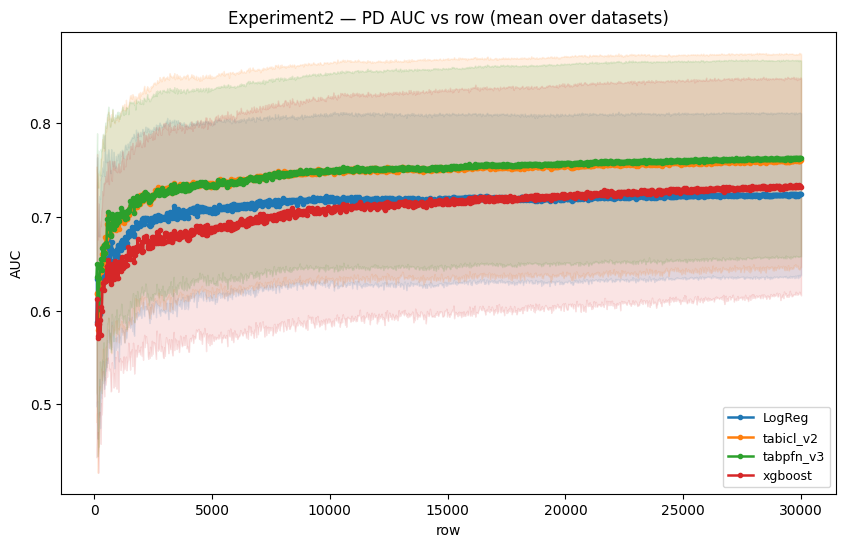

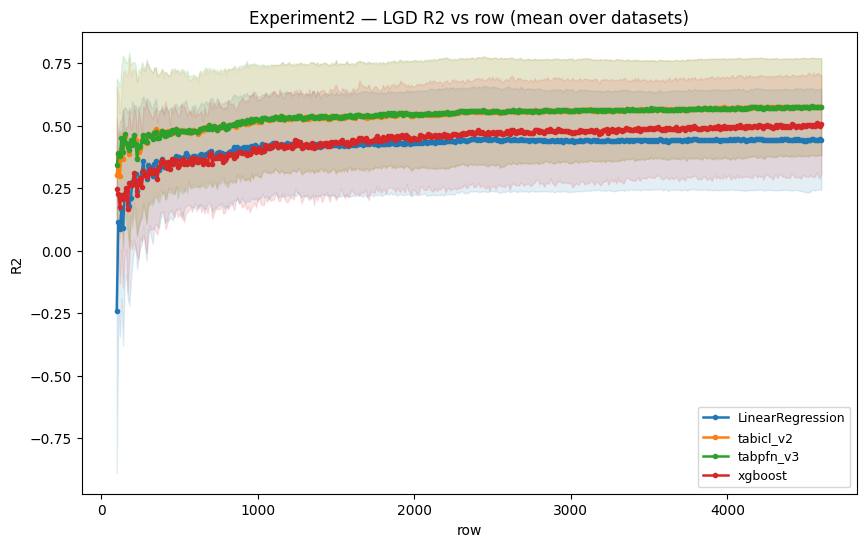

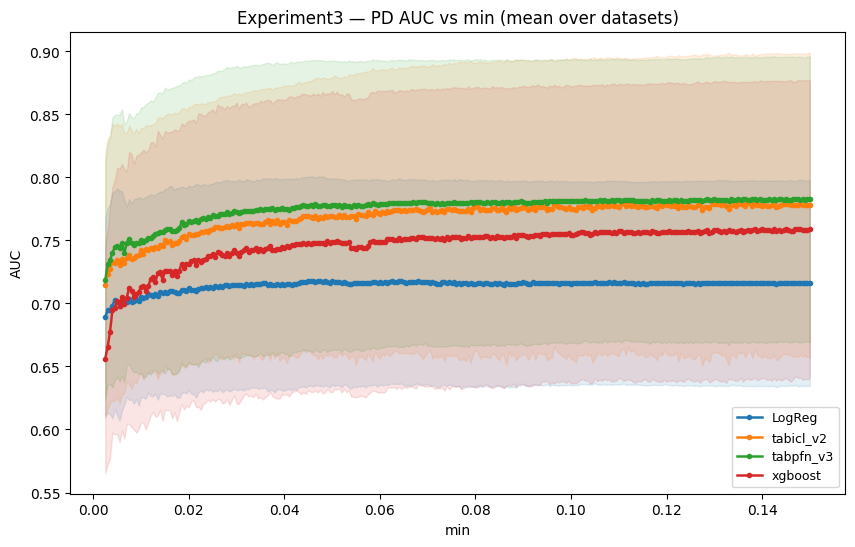

In [8]:
# Holes in a line reveal missing sweep points; band = +-1 std across datasets.
audit2 = rc.audit_experiment('Experiment2', results_root=RESULTS_ROOT)
rc.plot_sweep_curves(audit2, task='pd',  metric='AUC')
rc.plot_sweep_curves(audit2, task='lgd', metric='R2')
audit3 = rc.audit_experiment('Experiment3', results_root=RESULTS_ROOT)
rc.plot_sweep_curves(audit3, task='pd', metric='AUC')